# 4.0 — Análisis comparativo del benchmark — Food-101

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/marcoslund/ViT-for-101-food-app/blob/main/notebooks/4.0-comparativa.ipynb)

Este notebook consolida los resultados de las cuatro corridas (`3.1` a `3.4`) y los analiza de cara al informe. No entrena ni evalúa modelos: trabaja sobre lo que cada corrida dejó en `reports/results/<modelo>/` —métricas, predicciones por imagen, reporte por clase, confusiones e historial de entrenamiento— y sobre los artefactos del EDA en `data/processed/`.

| Modelo | Checkpoint | Parámetros | Rol en el benchmark |
|---|---|---|---|
| **MobileViT-S** | `apple/mobilevit-small` | 5,0 M | candidato liviano |
| **DeiT-Ti** | `facebook/deit-tiny-patch16-224` | 5,5 M | liviano, transformer puro |
| **Swin-T** | `microsoft/swin-tiny-patch4-window7-224` | 27,6 M | intermedio |
| **ViT-B/16** | `google/vit-base-patch16-224-in21k` | 85,9 M | referencia de mayor capacidad |

**Qué produce** (lo que el informe va a citar):

- tablas en `reports/results/comparativa/*.csv` y los números clave en `reports/results/comparativa/hallazgos.json`;
- figuras en `reports/figures/comparativa-*.png` y grillas con imágenes del dataset en `reports/figures/comparativa-ejemplos-*.jpg`.

**Qué necesita:** las dependencias base del proyecto. No hace falta GPU ni el extra `deep`. Solo la sección 7 (ejemplos del dataset) necesita las imágenes de Food-101: alcanza con el `food-101.tar.gz` sin extraer, del que se sacan únicamente las ~60 imágenes que se muestran.

La lógica vive en `vit_for_101_food_app/modeling/comparison.py` y `modeling/examples.py` (con tests en `tests/`); acá solo se llaman funciones.

## 0. Entorno

Desde la raíz del repo:

```bash
uv sync
uv run jupyter lab
```

### 0.1 Parámetros

- `MOSTRAR_IMAGENES`: genera las grillas de la sección 7. Si las imágenes no están disponibles, la sección se saltea sin cortar el notebook.
- `USE_DRIVE` (solo Colab): busca el `food-101.tar.gz` en `DRIVE_DIR`, donde lo dejan los notebooks 3.x.
- `REPO_BRANCH`: rama que clona Colab.

In [1]:
MOSTRAR_IMAGENES = True

# Solo Colab
USE_DRIVE = True
DRIVE_DIR = "/content/drive/MyDrive/ceia-vpc3"
REPO_BRANCH = "main"

### 0.2 Instalación (Colab) e imports

In [2]:
import os
from pathlib import Path
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

if IN_COLAB:
    REPO_URL = "https://github.com/marcoslund/ViT-for-101-food-app.git"
    REPO_DIR = "/content/ViT-for-101-food-app"
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "-q", "-b", REPO_BRANCH, REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull", "-q"], check=False)
    sys.path.insert(0, REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", REPO_DIR], check=True)
    os.chdir(f"{REPO_DIR}/notebooks")
    if USE_DRIVE:
        from google.colab import drive

        drive.mount("/content/drive")

print(f"Colab: {IN_COLAB}")

Colab: False


In [3]:
import json

from IPython.display import Image, display
from loguru import logger
import matplotlib.pyplot as plt
import pandas as pd

# config.py loguea la ruta absoluta del proyecto al importarse: no aporta al análisis.
logger.disable("vit_for_101_food_app.config")

from vit_for_101_food_app.config import FIGURES_DIR, REPORTS_DIR
from vit_for_101_food_app.modeling import comparison as cmp
from vit_for_101_food_app.modeling import examples as ej

pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

OUT_DIR = REPORTS_DIR / "results" / "comparativa"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

REF = cmp.REFERENCE
MODELOS = cmp.available_models()
NOMBRE = cmp.model_name
print("modelos con resultados:", [NOMBRE(m) for m in MODELOS])
print("referencia:", NOMBRE(REF))


def guardar(fig, nombre):
    ruta = FIGURES_DIR / f"comparativa-{nombre}.png"
    fig.savefig(ruta, dpi=150, bbox_inches="tight")
    print("figura:", ruta.relative_to(REPORTS_DIR.parent))


def mostrar_grilla(fig, nombre):
    # Las grillas de fotos se guardan en JPEG: en PNG pesan diez veces más.
    ruta = FIGURES_DIR / f"comparativa-{nombre}.jpg"
    fig.savefig(ruta, dpi=110, bbox_inches="tight", pil_kwargs={"quality": 85})
    plt.close(fig)
    print("figura:", ruta.relative_to(REPORTS_DIR.parent))
    display(Image(filename=ruta))


# Se va llenando a lo largo del notebook y se exporta en la sección 9.
hallazgos = {}

modelos con resultados: ['MobileViT-S', 'ViT-B/16', 'Swin-T', 'DeiT-Ti']
referencia: ViT-B/16


## 1. Condiciones de la comparación

Para que las diferencias medidas sean diferencias entre arquitecturas, todo lo demás tiene que ser igual. `check_comparable` corta si la receta difiere entre corridas (learning rate, tope de épocas, batch efectivo, semilla, criterio de selección, tamaño de test). Las épocas efectivamente entrenadas sí pueden diferir: las define el early stopping.

El entorno se muestra pero no corta: importa porque las latencias de la sección 4 solo se pueden comparar si se midieron en la misma máquina.

In [4]:
metrics = cmp.load_metrics(MODELOS)
condiciones = cmp.check_comparable(metrics)
cmp.present(condiciones)

,MobileViT-S,ViT-B/16,Swin-T,DeiT-Ti
Épocas (tope),20,20,20,20
Learning rate,0.0005,0.0005,0.0005,0.0005
Weight decay,0.01,0.01,0.01,0.01
Warmup,0.05,0.05,0.05,0.05
Paciencia (early stopping),3,3,3,3
Métrica de selección,f1_macro,f1_macro,f1_macro,f1_macro
Semilla,42,42,42,42
Batch efectivo,32,32,32,32
Épocas entrenadas,17.0,20.0,20.0,20.0
Imágenes de test,25250,25250,25250,25250


Las cuatro corridas comparten receta, versiones y GPU (una RTX 5060 de notebook). Solo MobileViT-S cortó antes del tope de 20 épocas por early stopping; la sección 8 vuelve sobre eso.

## 2. Resultados globales

Una fila por modelo, con el desempeño sobre el **test completo** (25.250 imágenes, 250 por clase) y el costo arquitectónico.

Dos columnas necesitan aclaración:

- **Tamaño int8, cota teórica** es el tamaño fp32 dividido por cuatro. **Tamaño int8, medido** es el del modelo realmente cuantizado con cuantización dinámica de las capas `nn.Linear`, que es el que se midió en CPU. No coinciden cuando el modelo tiene muchas capas que no son lineales: es el caso de MobileViT-S, que combina convoluciones con bloques transformer.
- **Latencia CPU int8** es la mediana con batch 1 y un solo hilo del modelo cuantizado: es la medición más cercana a lo que pasaría en un dispositivo con recursos acotados.

In [5]:
resumen = cmp.summary_table(metrics)
resumen.to_csv(OUT_DIR / "tabla_comparativa.csv")
cmp.present(resumen.drop(columns="checkpoint"))

,Accuracy,Accuracy top-5,F1 macro,Parámetros (M),GFLOPs,Tamaño fp32 (MB),"Tamaño int8, cota teórica (MB)","Tamaño int8, medido (MB)",Latencia CPU fp32 (ms),Latencia CPU int8 (ms),Latencia GPU (ms),Épocas entrenadas,Horas de entrenamiento
MobileViT-S,0.8605,0.9688,0.8609,5.0024,4.0005,19.0825,4.7706,10.8481,105.7017,74.5258,9.7853,17.0,1.6714
ViT-B/16,0.8239,0.9490,0.8233,85.8763,35.1263,327.5922,81.8980,84.4885,307.4258,200.7379,6.1292,20.0,3.1189
Swin-T,0.8548,0.9664,0.8547,27.5970,8.9798,105.2743,26.3186,26.7229,181.9656,89.1115,29.1606,20.0,1.9403
DeiT-Ti,0.7768,0.9314,0.7765,5.5439,2.5070,21.1483,5.2871,6.0231,50.3848,19.0370,6.4546,20.0,1.0377


In [6]:
for m in MODELOS:
    hallazgos[f"{m}_accuracy"] = float(resumen.loc[m, "accuracy"])
    hallazgos[f"{m}_f1_macro"] = float(resumen.loc[m, "f1_macro"])

ranking = resumen["f1_macro"].sort_values(ascending=False)
print("Ranking por F1 macro en test:")
for i, (m, f1) in enumerate(ranking.items(), 1):
    print(f"  {i}. {NOMBRE(m):12s} {f1:.4f}")

Ranking por F1 macro en test:
  1. MobileViT-S  0.8609
  2. Swin-T       0.8547
  3. ViT-B/16     0.8233
  4. DeiT-Ti      0.7765


**Lectura.** MobileViT-S, con 5 M de parámetros, obtiene el mejor F1 macro del benchmark (0,861), seguido muy de cerca por Swin-T (0,855). La referencia, ViT-B/16, queda tercera (0,823) pese a tener 17 veces más parámetros que MobileViT-S. DeiT-Ti, de tamaño parecido a MobileViT-S, queda última (0,777). Accuracy y F1 macro prácticamente coinciden en todos los modelos, como es de esperar en un test balanceado.

## 3. Diferencias pareadas entre modelos

Los cuatro modelos predijeron exactamente las mismas 25.250 imágenes, así que se pueden comparar **imagen por imagen**. Cada fila de las tablas de esta sección compara un modelo A contra un modelo B:

- **Diferencia A − B**: cuántos puntos porcentuales de accuracy le saca A a B (positiva: A acierta más). Las imágenes que aciertan o fallan los dos no distinguen a uno del otro; la diferencia sale de las columnas *Acierta solo A* y *Acierta solo B*.
- **IC 95 %**: el test es una muestra de todas las fotos posibles de estos platos, así que otra muestra daría una diferencia algo distinta. El intervalo de confianza es el rango de diferencias compatibles con lo observado: si no incluye el 0, la ventaja de A no se explica por el azar de qué imágenes tocaron en el test.
- **p (McNemar)**: el test de McNemar compara cuántas imágenes acierta solo A contra cuántas acierta solo B; si los dos modelos fueran igual de buenos esos conteos deberían ser parecidos, y el p-valor indica qué tan improbable sería, en ese caso, el desbalance observado.

Primero, cada modelo (A) contra la referencia (B = ViT-B/16):

In [7]:
preds = cmp.load_predictions(MODELOS)
dif_ref = cmp.differences_vs(preds, MODELOS, REF)
dif_ref.to_csv(OUT_DIR / "diferencias_vs_referencia.csv")
cmp.present_paired(dif_ref.rename(index=lambda m: f"{NOMBRE(m)} − {NOMBRE(REF)}"))

,Imágenes,Accuracy de A (%),Accuracy de B (%),Diferencia A − B (puntos),"IC 95 %, desde (puntos)","IC 95 %, hasta (puntos)",Acierta solo A,Acierta solo B,p (McNemar)
MobileViT-S − ViT-B/16,25250,86.0475,82.3881,3.6594,3.1865,4.1323,2335,1411,< 0.001
Swin-T − ViT-B/16,25250,85.4812,82.3881,3.0931,2.6589,3.5273,1967,1186,< 0.001
DeiT-Ti − ViT-B/16,25250,77.6752,82.3881,-4.7129,-5.1691,-4.2567,1160,2350,< 0.001


Después, los candidatos entre sí, que es la comparación que decide qué modelo conviene para el dispositivo:

In [8]:
pares = [("mobilevit", "swin"), ("mobilevit", "deit"), ("swin", "deit")]
entre = pd.DataFrame(
    {f"{NOMBRE(a)} − {NOMBRE(b)}": cmp.paired_difference(preds[a], preds[b]) for a, b in pares}
).T
entre.to_csv(OUT_DIR / "diferencias_entre_candidatos.csv")

for m in dif_ref.index:
    for k in ("diff", "ic_bajo", "ic_alto", "p_mcnemar"):
        hallazgos[f"{m}_vs_{REF}_{k}"] = float(dif_ref.loc[m, k])
mv_sw = cmp.paired_difference(preds["mobilevit"], preds["swin"])
hallazgos.update({f"mobilevit_vs_swin_{k}": mv_sw[k] for k in ("diff", "ic_bajo", "ic_alto", "p_mcnemar")})

cmp.present_paired(entre)

,Imágenes,Accuracy de A (%),Accuracy de B (%),Diferencia A − B (puntos),"IC 95 %, desde (puntos)","IC 95 %, hasta (puntos)",Acierta solo A,Acierta solo B,p (McNemar)
MobileViT-S − Swin-T,25250,86.0475,85.4812,0.5663,0.1293,1.0034,1657,1514,0.012
MobileViT-S − DeiT-Ti,25250,86.0475,77.6752,8.3723,7.8642,8.8804,3288,1174,< 0.001
Swin-T − DeiT-Ti,25250,85.4812,77.6752,7.8059,7.3378,8.2741,2881,910,< 0.001


**Lectura.** Las tres diferencias contra la referencia son claramente distintas de cero (p < 0,001): MobileViT-S la supera por unos 3,7 puntos de accuracy (IC 95 % de 3,2 a 4,1), Swin-T por unos 3,1 y DeiT-Ti queda unos 4,7 puntos por debajo. Entre candidatos, MobileViT-S supera a Swin-T por 0,6 puntos (IC 95 % de 0,1 a 1,0; p ≈ 0,01): con 25.250 imágenes la diferencia es estadísticamente detectable, pero en la práctica los dos rinden igual. La distancia entre MobileViT-S y DeiT-Ti, en cambio, es grande (unos 8 puntos), aunque tengan casi la misma cantidad de parámetros.

## 4. Desempeño frente al costo

Un panel por eje de costo, sin mezclar dos escalas en un mismo gráfico.

Un modelo está en el **frente de Pareto** de un eje si ningún otro modelo es a la vez más barato y mejor en F1. Son las opciones que no se pueden descartar: para mejorar el F1 hay que pagar más costo, o para bajar el costo hay que resignar F1. Los modelos que no están en el frente, en cambio, están *dominados*: hay otro que es mejor y más barato. En cada panel, los modelos del frente llevan un anillo y, si son más de uno, una línea punteada que los une. En el panel de parámetros no hay línea porque el frente tiene un solo modelo: MobileViT-S es a la vez el de menos parámetros y el de mejor F1, así que domina a los otros tres.

La latencia en **GPU** queda afuera a propósito: con una sola imagen por vez domina el costo fijo de lanzar kernels, y por eso ViT-B/16 (86 M de parámetros) sale tan rápido como DeiT-Ti (5,5 M). Esa medición no dice nada sobre un dispositivo.

figura: reports/figures/comparativa-f1-vs-costo.png


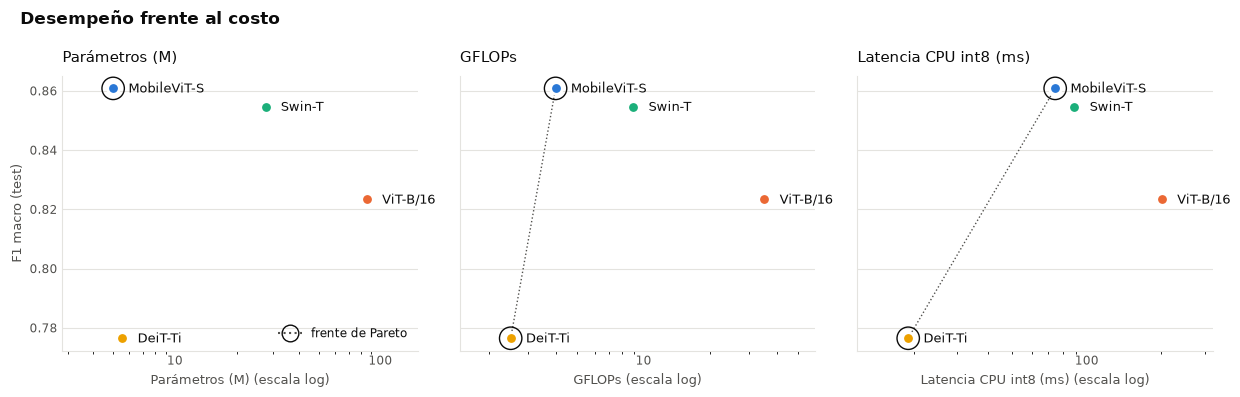

,Pareto en Parámetros (M),Pareto en GFLOPs,Pareto en Latencia CPU int8 (ms)
MobileViT-S,True,True,True
ViT-B/16,False,False,False
Swin-T,False,False,False
DeiT-Ti,False,True,True


In [9]:
EJES_COSTO = {
    "params_m": "Parámetros (M)",
    "gflops": "GFLOPs",
    "cpu_int8_ms": "Latencia CPU int8 (ms)",
}
fig = cmp.plot_tradeoff(resumen, EJES_COSTO)
guardar(fig, "f1-vs-costo")
plt.show()

pareto = pd.concat([cmp.pareto_front(resumen, col) for col in EJES_COSTO], axis=1)
pareto.columns = [f"Pareto en {etiqueta}" for etiqueta in EJES_COSTO.values()]
pareto.to_csv(OUT_DIR / "frente_de_pareto.csv")
pareto.rename(index=NOMBRE)

In [10]:
costo_rel = pd.DataFrame(
    {
        "Parámetros": resumen["params_m"] / resumen.loc["mobilevit", "params_m"],
        "GFLOPs": resumen["gflops"] / resumen.loc["mobilevit", "gflops"],
        "Latencia CPU int8": resumen["cpu_int8_ms"] / resumen.loc["mobilevit", "cpu_int8_ms"],
        "Tamaño int8 medido": resumen["size_mb_int8_medido"] / resumen.loc["mobilevit", "size_mb_int8_medido"],
    }
)
for col, clave in (("Parámetros", "params"), ("GFLOPs", "gflops"), ("Latencia CPU int8", "cpu_int8")):
    hallazgos[f"{REF}_sobre_mobilevit_{clave}"] = float(costo_rel.loc[REF, col])
    hallazgos[f"deit_sobre_mobilevit_{clave}"] = float(costo_rel.loc["deit", col])

print("Costo de cada modelo relativo a MobileViT-S (1 = igual):")
costo_rel.rename(index=NOMBRE).round(2)

Costo de cada modelo relativo a MobileViT-S (1 = igual):


,Parámetros,GFLOPs,Latencia CPU int8,Tamaño int8 medido
MobileViT-S,1.00,1.00,1.00,1.00
ViT-B/16,17.17,8.78,2.69,7.79
Swin-T,5.52,2.24,1.20,2.46
DeiT-Ti,1.11,0.63,0.26,0.56


**Lectura.** MobileViT-S está en el frente de Pareto en los tres ejes: ningún otro modelo es a la vez más barato y mejor. DeiT-Ti también está en el frente en GFLOPs y latencia, porque es el más rápido de todos (unos 19 ms en CPU int8 contra 75 ms de MobileViT-S), pero paga esa velocidad con unos 8 puntos de accuracy. Swin-T y ViT-B/16 quedan dominados en todos los ejes.

Hay un matiz que el informe no debería perder: tener pocos parámetros no implica ser rápido. MobileViT-S tiene menos parámetros que DeiT-Ti pero más GFLOPs (en parte porque trabaja a 256 px en lugar de 224, y sus convoluciones operan sobre mapas de alta resolución) y casi cuatro veces su latencia en CPU. Además, la cuantización dinámica apenas lo achica (de 19 a 11 MB, lejos de la cota de 4,8 MB) porque solo cuantiza las capas lineales.

## 5. Rendimiento según la dificultad de la clase

En el EDA, cada clase recibió un **margen** de dificultad (cuánto se parece a su vecina más cercana en el espacio de embeddings de CLIP) y, a partir de él, un tercil: fácil, medio o difícil. Ese ranking se fijó **antes** de entrenar, así que sirve para analizar dónde se concentran las diferencias entre modelos sin riesgo de haberlo ajustado a los resultados.

### 5.1 Subset del benchmark

El subset de 25 imágenes por clase (2.525 en total) es el protocolo de evaluación que definió el EDA; `load_benchmark_subset` verifica su `sha256` antes de usarlo. Accuracy de cada modelo por tercil, tal como la registró cada corrida:

In [11]:
subset = cmp.load_benchmark_subset()
dificultad = cmp.load_class_difficulty()
etiqueta = dificultad["label"].to_dict()

por_tercil = pd.DataFrame(
    {m: {g: v["accuracy"] for g, v in metrics[m]["benchmark_por_tercil"].items()} for m in MODELOS}
).loc[["facil", "medio", "dificil", "subset"]]
por_tercil.to_csv(OUT_DIR / "accuracy_por_tercil_subset.csv")
cmp.present(por_tercil)

,MobileViT-S,ViT-B/16,Swin-T,DeiT-Ti
Fácil,0.9282,0.9082,0.9247,0.8776
Medio,0.8752,0.8327,0.8618,0.7818
Difícil,0.7824,0.7424,0.7882,0.7047
Subset,0.8618,0.8277,0.8582,0.7881


In [12]:
preds_t = cmp.with_tercil(preds, dificultad)

# El tercil del subset y el de class_difficulty.csv tienen que ser el mismo ranking.
control = subset[["rel", "tercil"]].merge(preds_t[["rel", "tercil"]], on="rel", suffixes=("_subset", ""))
assert (control["tercil_subset"] == control["tercil"]).all()

brecha_subset = cmp.gap_by_tercil(preds_t[preds_t["rel"].isin(subset["rel"])], MODELOS, REF)
brecha_subset.to_csv(OUT_DIR / "brecha_por_tercil_subset.csv", index=False)
# A = el modelo de la fila, B = la referencia
cmp.present_paired(brecha_subset[["tercil", "modelo", "n", "diff", "ic_bajo", "ic_alto", "p_mcnemar"]])

,Tercil,Modelo,Imágenes,Diferencia A − B (puntos),"IC 95 %, desde (puntos)","IC 95 %, hasta (puntos)",p (McNemar)
0,Fácil,MobileViT-S,850,2.0000,0.0345,3.9655,0.060
1,Fácil,Swin-T,850,1.6471,-0.1943,3.4884,0.103
2,Fácil,DeiT-Ti,850,-3.0588,-5.0585,-1.0592,0.004
3,Medio,MobileViT-S,825,4.2424,1.6891,6.7958,0.002
4,Medio,Swin-T,825,2.9091,0.5180,5.3002,0.022
5,Medio,DeiT-Ti,825,-5.0909,-7.5582,-2.6236,< 0.001
6,Difícil,MobileViT-S,850,4.0000,0.8838,7.1162,0.015
7,Difícil,Swin-T,850,4.5882,1.7155,7.4609,0.002
8,Difícil,DeiT-Ti,850,-3.7647,-6.5393,-0.9901,0.010


Con unas 850 imágenes por tercil, los intervalos son anchos (del orden de ±3 puntos): alcanzan para ver el signo de cada diferencia, pero no para comparar su tamaño entre terciles.

### 5.2 Test completo por tercil

El mismo ranking aplicado a las 25.250 imágenes de test (unas 8.500 por tercil). Complementa al protocolo del subset con diez veces más imágenes, lo que achica los intervalos a un tercio.

figura: reports/figures/comparativa-brecha-por-tercil.png


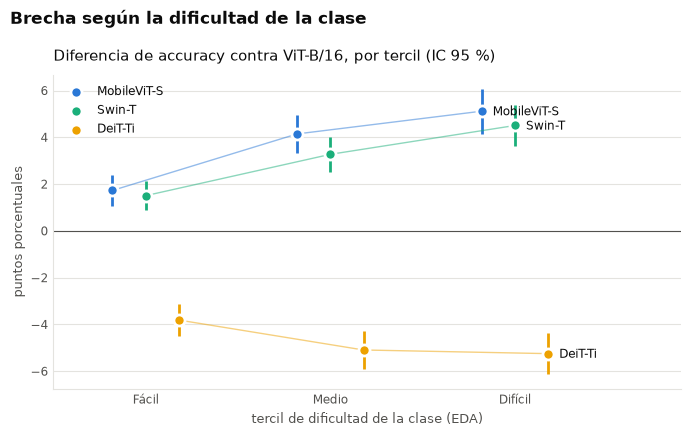

Diferencia de accuracy contra ViT-B/16, en puntos porcentuales:


tercil,Fácil,Medio,Difícil
modelo,,,
MobileViT-S,1.73,4.15,5.12
Swin-T,1.51,3.27,4.51
DeiT-Ti,-3.81,-5.09,-5.25


In [13]:
brecha_test = cmp.gap_by_tercil(preds_t, MODELOS, REF)
brecha_test.to_csv(OUT_DIR / "brecha_por_tercil_test.csv", index=False)

fig = cmp.plot_gap_by_tercil(brecha_test, REF)
guardar(fig, "brecha-por-tercil")
plt.show()

tabla_brecha = brecha_test.pivot(index="modelo", columns="tercil", values="diff")[list(cmp.TERCILES)] * 100
for m in tabla_brecha.index:
    for t in cmp.TERCILES:
        hallazgos[f"{m}_vs_{REF}_{t}_pp"] = float(tabla_brecha.loc[m, t])

print(f"Diferencia de accuracy contra {NOMBRE(REF)}, en puntos porcentuales:")
cmp.present(tabla_brecha.loc[[m for m in MODELOS if m != REF]]).round(2)

**Lectura.** La brecha no es pareja entre terciles. La ventaja de MobileViT-S y de Swin-T sobre la referencia **crece con la dificultad**: MobileViT-S le saca unos 1,7 puntos en las clases fáciles, 4,2 en las medias y 5,1 en las difíciles. DeiT-Ti pierde en los tres terciles, algo más en los medios y difíciles. Es decir: las diferencias entre arquitecturas aparecen sobre todo donde la tarea es difícil; en las clases fáciles todos los modelos rondan el 90 % y hay menos margen para separarse (efecto techo).

### 5.3 Clase por clase

El tercil agrupa 34 clases; acá se mira cada una. Para cada clase se grafica el F1 del modelo menos el F1 de la referencia contra su margen en el EDA (margen bajo: la clase se parece mucho a su vecina, es difícil).

La correlación de Spearman resume si la brecha depende de la dificultad: una brecha pareja da ρ cercano a 0. Como el margen crece hacia las clases fáciles, un ρ **negativo** indica que la brecha es mayor en las clases difíciles.

In [14]:
por_clase = cmp.per_class_gap(MODELOS, dificultad, REF)
por_clase.to_csv(OUT_DIR / "brecha_por_clase.csv")

planitud = pd.DataFrame([cmp.flatness(por_clase, m) for m in MODELOS if m != REF]).set_index("modelo")
planitud.to_csv(OUT_DIR / "brecha_vs_dificultad.csv")
for m in planitud.index:
    hallazgos[f"{m}_spearman_rho"] = float(planitud.loc[m, "spearman_rho"])
    hallazgos[f"{m}_clases_gana_vs_{REF}"] = int(planitud.loc[m, "clases_gana"])
cmp.present(planitud)

,Brecha media,Desvío de la brecha,Clases en que gana,Clases en que pierde,Spearman ρ,p (Spearman),Pendiente
modelo,,,,,,,
MobileViT-S,0.0375,0.0320,94,7,-0.3252,0.0009,-0.3364
Swin-T,0.0313,0.0260,94,6,-0.3566,0.0003,-0.3191
DeiT-Ti,-0.0468,0.0253,4,97,0.3745,0.0001,0.3034


figura: reports/figures/comparativa-brecha-por-clase-mobilevit.png


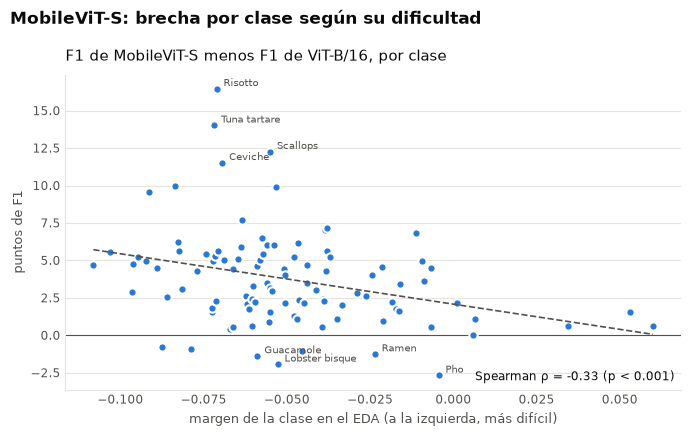

figura: reports/figures/comparativa-brecha-por-clase-swin.png


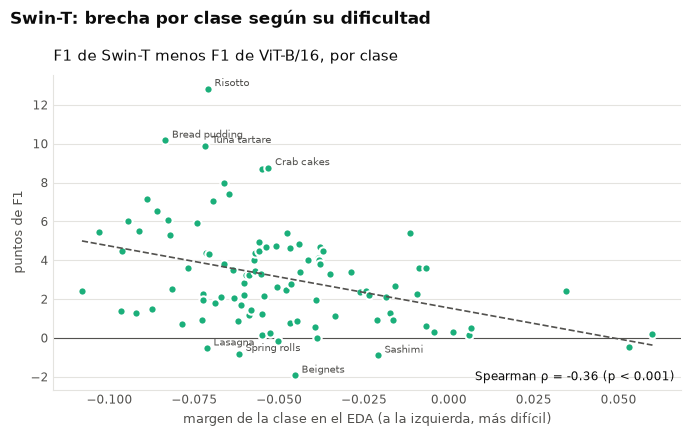

In [15]:
for m in ("mobilevit", "swin"):
    fig = cmp.plot_class_gap(por_clase, m, REF)
    guardar(fig, f"brecha-por-clase-{m}")
    plt.show()

Las clases donde MobileViT-S más le gana a la referencia y todas aquellas en que queda por debajo, con su vecina más confundible según el EDA. La diferencia de F1 va en puntos:

In [16]:
cols = ["label", "tercil", "vecino_mas_cercano", "f1_mobilevit", f"f1_{REF}", "gap_mobilevit"]
ordenadas = por_clase.sort_values("gap_mobilevit", ascending=False)
gana_clases = ordenadas[ordenadas["gap_mobilevit"] > 0]
pierde_clases = ordenadas[ordenadas["gap_mobilevit"] < 0].iloc[::-1]
MEJORES = gana_clases.index[:4].tolist()
PEORES = pierde_clases.index[:3].tolist()


def vista_clases(tabla):
    vista = tabla[cols].assign(gap_mobilevit=tabla["gap_mobilevit"] * 100)
    return cmp.present(vista.rename(columns={"gap_mobilevit": "Diferencia de F1 (puntos)"}))


print(f"Las 8 clases (de {len(gana_clases)}) donde MobileViT-S más supera a {NOMBRE(REF)}:")
display(vista_clases(gana_clases.head(8)))
print(f"Las {len(pierde_clases)} clases donde MobileViT-S queda por debajo de {NOMBRE(REF)}:")
display(vista_clases(pierde_clases))

Las 8 clases (de 94) donde MobileViT-S más supera a ViT-B/16:


,Clase,Tercil,Vecina más confundible,F1 MobileViT-S,F1 ViT-B/16,Diferencia de F1 (puntos)
risotto,Risotto,Difícil,Gnocchi,0.8178,0.6532,16.4588
tuna_tartare,Tuna tartare,Difícil,Beef tartare,0.8176,0.6774,14.0191
scallops,Scallops,Medio,Foie gras,0.8195,0.6969,12.2626
ceviche,Ceviche,Difícil,Tuna tartare,0.8218,0.7066,11.5191
bread_pudding,Bread pudding,Difícil,Apple pie,0.7078,0.6080,9.9787
crab_cakes,Crab cakes,Medio,Scallops,0.8251,0.7262,9.8957
chocolate_mousse,Chocolate mousse,Difícil,Tiramisu,0.7110,0.6151,9.5932
cannoli,Cannoli,Difícil,Beignets,0.9357,0.8588,7.6896


Las 7 clases donde MobileViT-S queda por debajo de ViT-B/16:


,Clase,Tercil,Vecina más confundible,F1 MobileViT-S,F1 ViT-B/16,Diferencia de F1 (puntos)
pho,Pho,Fácil,Ramen,0.9049,0.9317,-2.6784
lobster_bisque,Lobster bisque,Medio,Clam chowder,0.8584,0.8778,-1.9405
guacamole,Guacamole,Medio,Nachos,0.9058,0.9197,-1.3867
ramen,Ramen,Fácil,Pho,0.8834,0.8960,-1.2564
beignets,Beignets,Medio,Cannoli,0.8644,0.8748,-1.0383
strawberry_shortcake,Strawberry shortcake,Difícil,Cheesecake,0.8611,0.8701,-0.8968
prime_rib,Prime rib,Difícil,Steak,0.8502,0.8583,-0.8065


**Lectura.** MobileViT-S supera a la referencia en 94 de las 101 clases, y la correlación con el margen es negativa (ρ ≈ −0,33): gana más en las clases difíciles. Las mayores ventajas están en risotto, tuna tartare, scallops y ceviche, con 11 a 16 puntos de F1 de diferencia (la sección 7.2 muestra ejemplos). Las siete clases en que pierde lo hacen por márgenes chicos (menos de 3 puntos de F1) y están repartidas entre los tres terciles. Swin-T muestra el mismo patrón (ρ ≈ −0,36, gana en 94 clases).

## 6. Confusiones entre clases

Los pares (clase real → clase predicha) más frecuentes, con cuántas veces los cometió cada modelo. Están ordenados por el total: arriba quedan las confusiones que comparten todas las arquitecturas, que hablan más del dataset que de un modelo en particular.

In [17]:
confusiones = cmp.confusion_pairs(MODELOS, top=200)
confusiones.to_csv(OUT_DIR / "confusiones_compartidas.csv", index=False)

vista = confusiones.head(12).copy()
vista["clase_real"] = vista["clase_real"].map(etiqueta)
vista["clase_predicha"] = vista["clase_predicha"].map(etiqueta)
cmp.present(vista)

,Clase real,Clase predicha,MobileViT-S,ViT-B/16,Swin-T,DeiT-Ti,Total
0,Filet mignon,Steak,50,35,33,46,164
1,Steak,Filet mignon,35,38,40,46,159
2,Chocolate cake,Chocolate mousse,32,30,35,33,130
3,Pork chop,Steak,31,16,25,26,98
4,Tuna tartare,Beef tartare,26,27,17,28,98
5,Chocolate mousse,Chocolate cake,19,23,29,25,96
6,Prime rib,Steak,30,16,24,22,92
7,Apple pie,Bread pudding,19,18,19,15,71
8,Ravioli,Gnocchi,25,12,12,22,71
9,Pork chop,Filet mignon,10,21,15,20,66


In [18]:
todos_fallan = ~preds[MODELOS].any(axis=1)
todos_aciertan = preds[MODELOS].all(axis=1)
predicciones = preds[[f"pred_{m}" for m in MODELOS]]
misma_clase = todos_fallan & predicciones.nunique(axis=1).eq(1)

hallazgos["pct_aciertan_los_cuatro"] = float(todos_aciertan.mean() * 100)
hallazgos["pct_fallan_los_cuatro"] = float(todos_fallan.mean() * 100)
hallazgos["n_fallan_los_cuatro_misma_clase"] = int(misma_clase.sum())
por_tercil_fallan = preds_t.assign(f=todos_fallan).groupby("tercil")["f"].mean()[list(cmp.TERCILES)] * 100
for t in cmp.TERCILES:
    hallazgos[f"pct_fallan_los_cuatro_{t}"] = float(por_tercil_fallan[t])

print(f"aciertan los cuatro modelos: {todos_aciertan.mean():.1%}")
print(f"fallan los cuatro modelos:   {todos_fallan.mean():.1%} ({todos_fallan.sum()} imágenes)")
print(f"  ...y coinciden en la misma clase equivocada: {misma_clase.sum()} imágenes")
print("fallan los cuatro, por tercil (%):")
cmp.present(por_tercil_fallan.rename("fallan los cuatro (%)").to_frame()).round(2)

aciertan los cuatro modelos: 68.1%
fallan los cuatro modelos:   5.7% (1436 imágenes)
  ...y coinciden en la misma clase equivocada: 331 imágenes
fallan los cuatro, por tercil (%):


,fallan los cuatro (%)
tercil,
Fácil,3.20
Medio,5.16
Difícil,8.68


**Lectura.** Las confusiones dominantes son las mismas para los cuatro modelos: steak ↔ filet mignon, chocolate cake ↔ chocolate mousse, tuna tartare ↔ beef tartare, y los cortes de carne (pork chop, prime rib) predichos como steak. Todas las clases involucradas pertenecen al tercil difícil del EDA, y en tres de esos pares (steak ↔ filet mignon, los dos tartares, prime rib → steak) el EDA ya había identificado a la otra clase como la vecina más cercana. El 68 % de las imágenes de test las aciertan los cuatro modelos y el 5,7 % las fallan todos; ese núcleo de errores comunes casi se triplica del tercil fácil (3,2 %) al difícil (8,7 %). En 331 imágenes los cuatro modelos coinciden además en la misma clase equivocada: son candidatas a imágenes genuinamente ambiguas (o a etiquetas discutibles), y la sección 7.4 muestra algunas.

## 7. Ejemplos del dataset

Las métricas dicen cuánto acierta cada modelo; las imágenes muestran en qué. Las grillas se arman a partir de las predicciones por imagen, con semilla fija, así que la selección es reproducible. Cada imagen se muestra recortada al cuadrado central, como la ve el modelo.

Las imágenes se buscan en el cache (`data/interim/food-101-288`), en el dataset extraído (`data/raw/food-101/images`) o, si no están, se sacan del `food-101.tar.gz` sin extraerlo entero. La primera vez eso implica recorrer el archivo de 5 GB (uno o dos minutos); después quedan en `data/interim/comparativa-imagenes/`, que no se versiona.

In [19]:
TAR = ej.TAR_PATH
if IN_COLAB and USE_DRIVE and Path(DRIVE_DIR, "food-101.tar.gz").is_file():
    TAR = Path(DRIVE_DIR, "food-101.tar.gz")

hay_imagenes = MOSTRAR_IMAGENES and (TAR.is_file() or any(ej.locate(preds["rel"].head(50)).values()))
print("fuente de imágenes:", TAR.name if TAR.is_file() else "cache / dataset extraído")
print("se muestran ejemplos:", hay_imagenes)
if MOSTRAR_IMAGENES and not hay_imagenes:
    print("No se encontraron las imágenes: correr `make data` o dejar food-101.tar.gz en data/raw/.")

fuente de imágenes: food-101.tar.gz
se muestran ejemplos: True


In [20]:
# Selección de todas las imágenes de la sección, para extraerlas del tar en una sola pasada.
aciertos = preds[MODELOS].sum(axis=1)


def cuantos_predicen(clase):
    return (predicciones == clase).sum(axis=1)


# 7.1: los pares más confundidos. Por clase, dos aciertos de los cuatro modelos y una
# imagen que al menos tres modelos ven como la otra clase del par.
PARES = cmp.unordered_pairs(confusiones, top=4)
filas_pares, sel_pares = [], []
for par in PARES.itertuples():
    imagenes = []
    for real, otra in ((par.clase_a, par.clase_b), (par.clase_b, par.clase_a)):
        # Una clase puede aparecer en más de un par (steak): no repetir imágenes.
        de_la_clase = (preds["class_dir"] == real) & ~preds["rel"].isin(sel_pares)
        tipicas = ej.pick(preds, de_la_clase & todos_aciertan, [real], per_class=2)
        k = cuantos_predicen(otra)
        confundida = ej.pick(preds, de_la_clase & (k >= 3), [real], per_class=1)
        imagenes += [(r, f"{etiqueta[real]}\nla aciertan los 4") for r in tipicas["rel"]]
        imagenes += [
            (r, f"{etiqueta[real]}\n{k[i]}/4 la ven como\n{etiqueta[otra]}")
            for i, r in zip(confundida.index, confundida["rel"])
        ]
        sel_pares += list(tipicas["rel"]) + list(confundida["rel"])
    filas_pares.append(
        (f"{etiqueta[par.clase_a]} ↔ {etiqueta[par.clase_b]} · {par.total} confusiones entre los cuatro modelos", imagenes)
    )

# 7.2 y 7.3: clases donde MobileViT-S más gana y más pierde contra la referencia.
gana = ej.pick(preds, preds["mobilevit"] & ~preds[REF], MEJORES, per_class=4)
pierde = ej.pick(preds, ~preds["mobilevit"] & preds[REF], PEORES, per_class=4)

# 7.4: imágenes que los cuatro modelos fallan prediciendo la misma clase.
comunes = ej.pick(preds, misma_clase, n=8)

rutas = {}
if hay_imagenes:
    todas = sel_pares + list(gana["rel"]) + list(pierde["rel"]) + list(comunes["rel"])
    rutas = ej.ensure_images(todas, TAR)
    print(f"{len(rutas)} de {len(set(todas))} imágenes disponibles")

60 de 60 imágenes disponibles


### 7.1 Los pares que más se confunden

Para cada uno de los cuatro pares con más confusiones (sumando los dos sentidos y los cuatro modelos): dos imágenes típicas de cada clase, que los cuatro modelos aciertan, y una imagen que al menos tres modelos asignan a la otra clase del par.

figura: reports/figures/comparativa-ejemplos-pares-confundidos.jpg


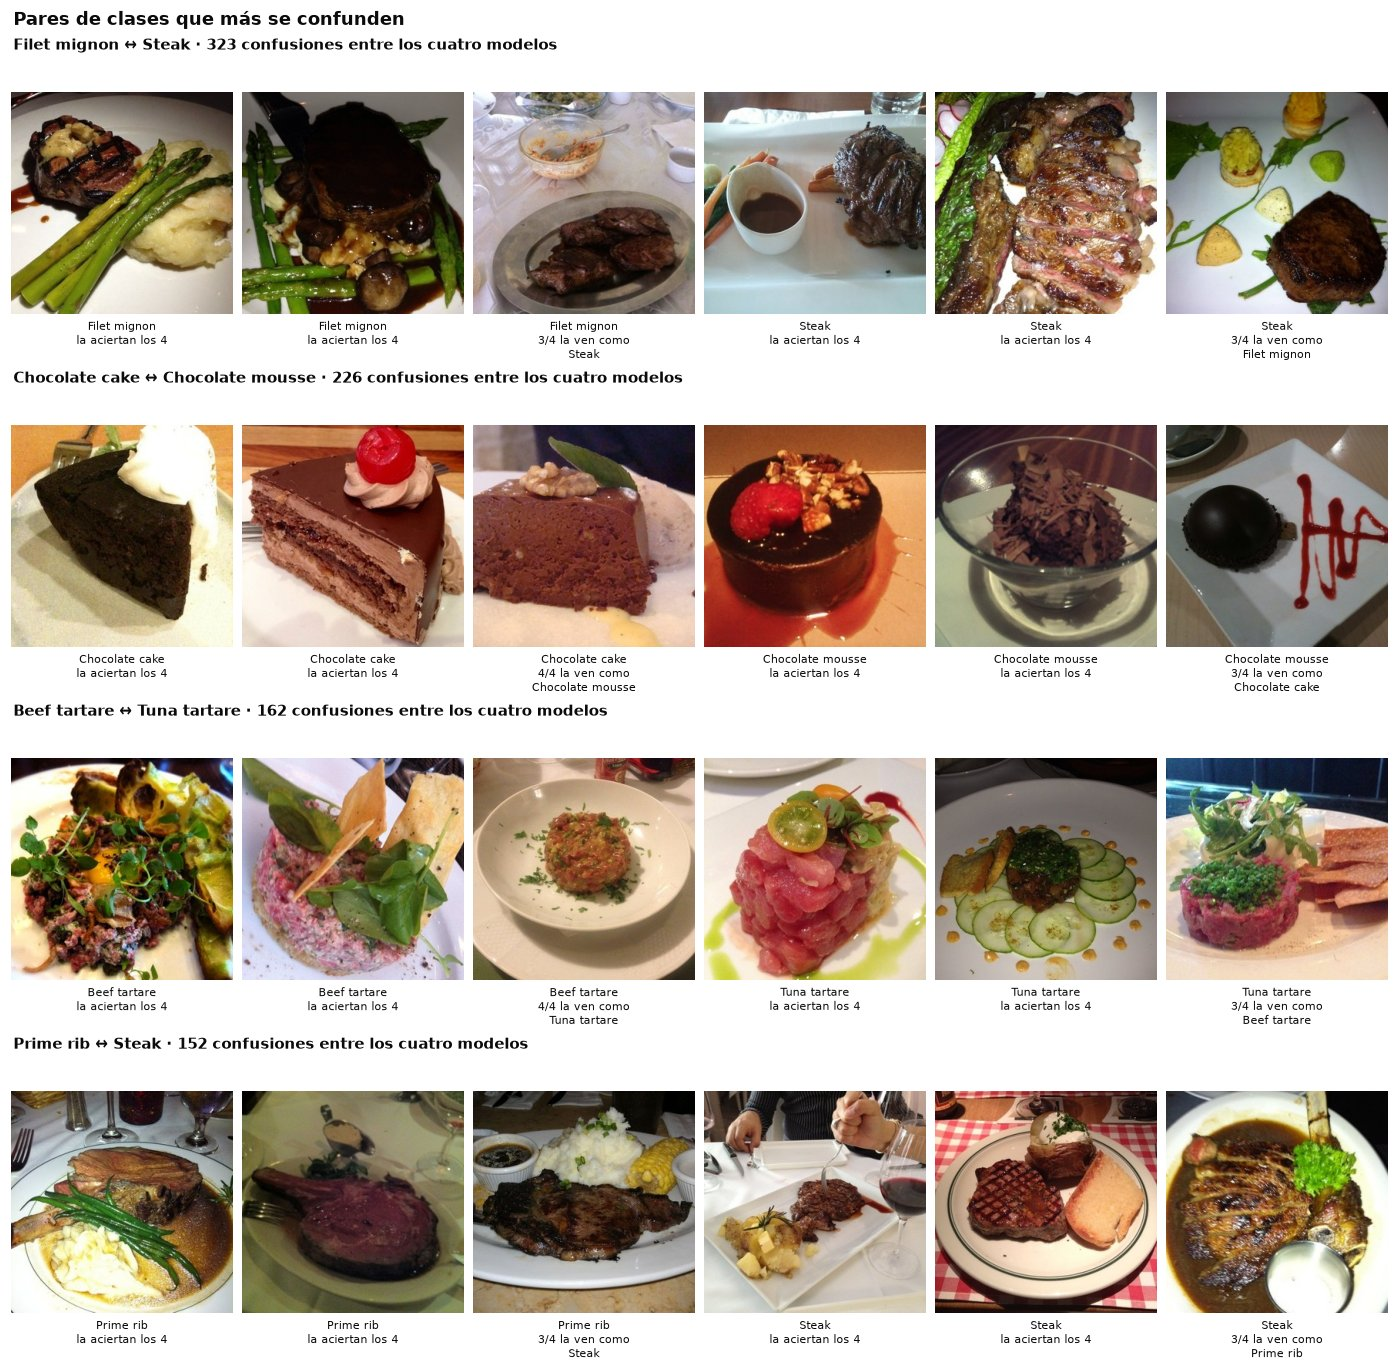

In [21]:
if hay_imagenes:
    fig = ej.plot_rows(filas_pares, rutas, "Pares de clases que más se confunden")
    mostrar_grilla(fig, "ejemplos-pares-confundidos")

Las imágenes explican las confusiones mejor que la tabla. Steak, filet mignon y prime rib son, en la foto, el mismo objeto: carne cocida en un plato, muchas veces con guarnición y salsa encima; lo que las distingue es el corte y el grosor, que desde el ángulo de la foto muchas veces no se ve. Entre chocolate cake y chocolate mousse, las imágenes confundidas son justamente las que se parecen a la otra clase: una torta densa sin capas visibles, o una mousse moldeada que se sirve entera en el plato, como si fuera una porción de torta. Los dos tartares comparten la presentación (un cilindro de proteína cruda picada con guarnición) y se distinguen sobre todo por el color, que la iluminación del restaurante altera.

### 7.2 Donde MobileViT-S supera a la referencia

Las cuatro clases con mayor ventaja de MobileViT-S sobre ViT-B/16. Cada imagen la acierta MobileViT-S y la falla ViT-B/16; el epígrafe dice qué predijo la referencia.

figura: reports/figures/comparativa-ejemplos-mobilevit-supera-vit.jpg


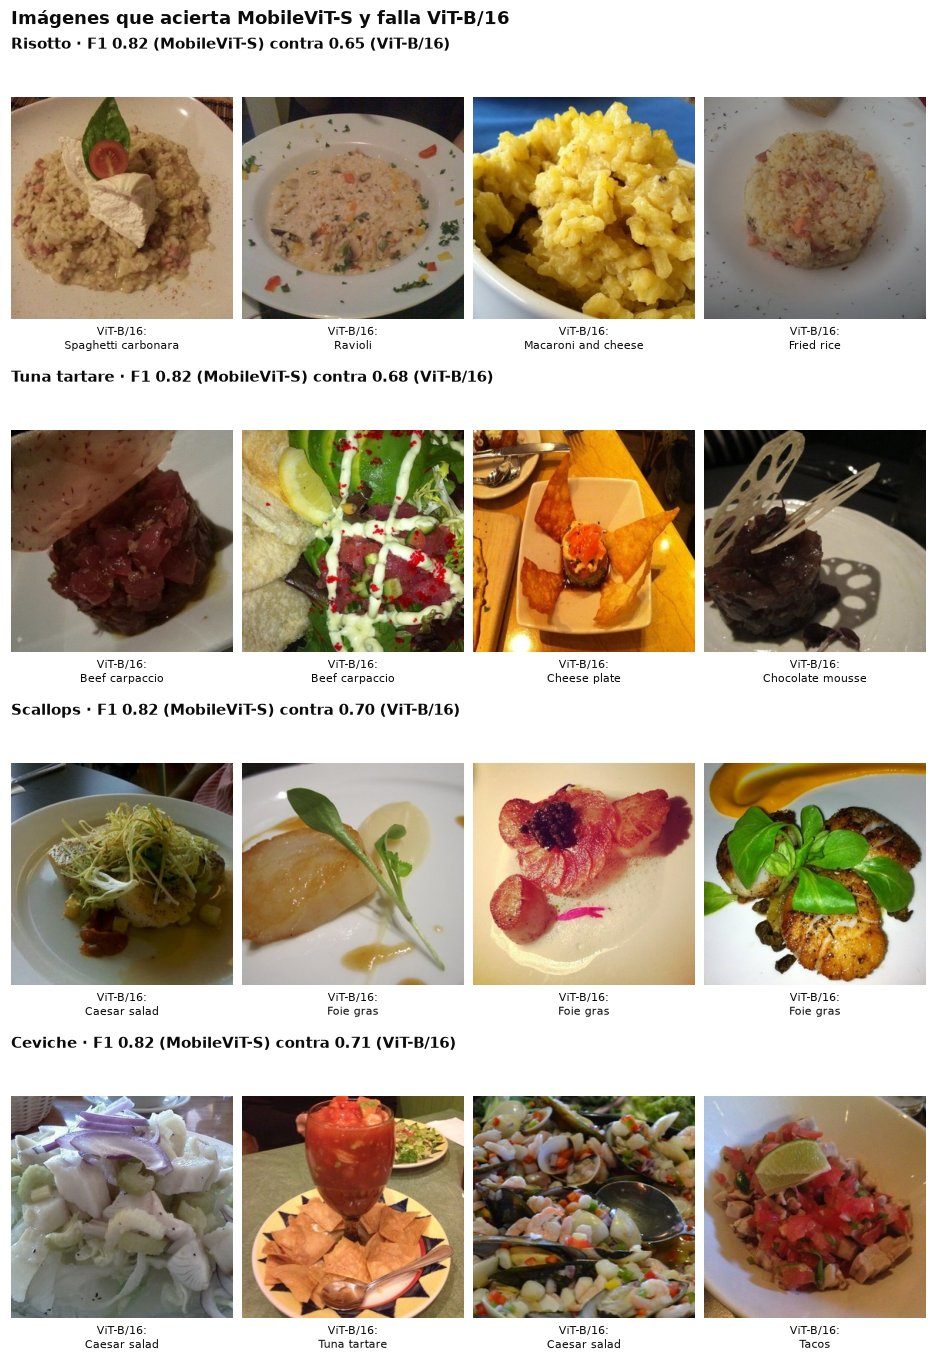

In [22]:
if hay_imagenes:
    filas = ej.rows_by_class(
        gana,
        caption=lambda r: f"{NOMBRE(REF)}:\n{etiqueta[getattr(r, 'pred_' + REF)]}",
        row_title=lambda c: (
            f"{etiqueta[c]} · F1 {por_clase.loc[c, 'f1_mobilevit']:.2f} (MobileViT-S) "
            f"contra {por_clase.loc[c, 'f1_' + REF]:.2f} ({NOMBRE(REF)})"
        ),
    )
    fig = ej.plot_rows(filas, rutas, f"Imágenes que acierta MobileViT-S y falla {NOMBRE(REF)}")
    mostrar_grilla(fig, "ejemplos-mobilevit-supera-vit")

Los errores de la referencia son hacia platos con la misma presentación general: el risotto hacia pastas y arroces (spaghetti carbonara, ravioli, macaroni and cheese, fried rice), los scallops hacia foie gras (una pieza dorada sobre plato blanco), el tuna tartare hacia beef carpaccio y el ceviche, sobre todo, hacia caesar salad. MobileViT-S separa bien estos casos, en los que la diferencia está en la textura del ingrediente (el grano de arroz, la superficie sellada de la vieira) más que en la forma del plato. Una hipótesis razonable es que las convoluciones de MobileViT-S capturan mejor esa textura local; no se verifica en este trabajo, y parte de la diferencia puede deberse a que ViT-B/16 no terminó de converger (sección 8).

### 7.3 Donde la referencia supera a MobileViT-S

Las tres clases donde MobileViT-S queda más por debajo de ViT-B/16. Cada imagen la acierta la referencia y la falla MobileViT-S.

figura: reports/figures/comparativa-ejemplos-vit-supera-mobilevit.jpg


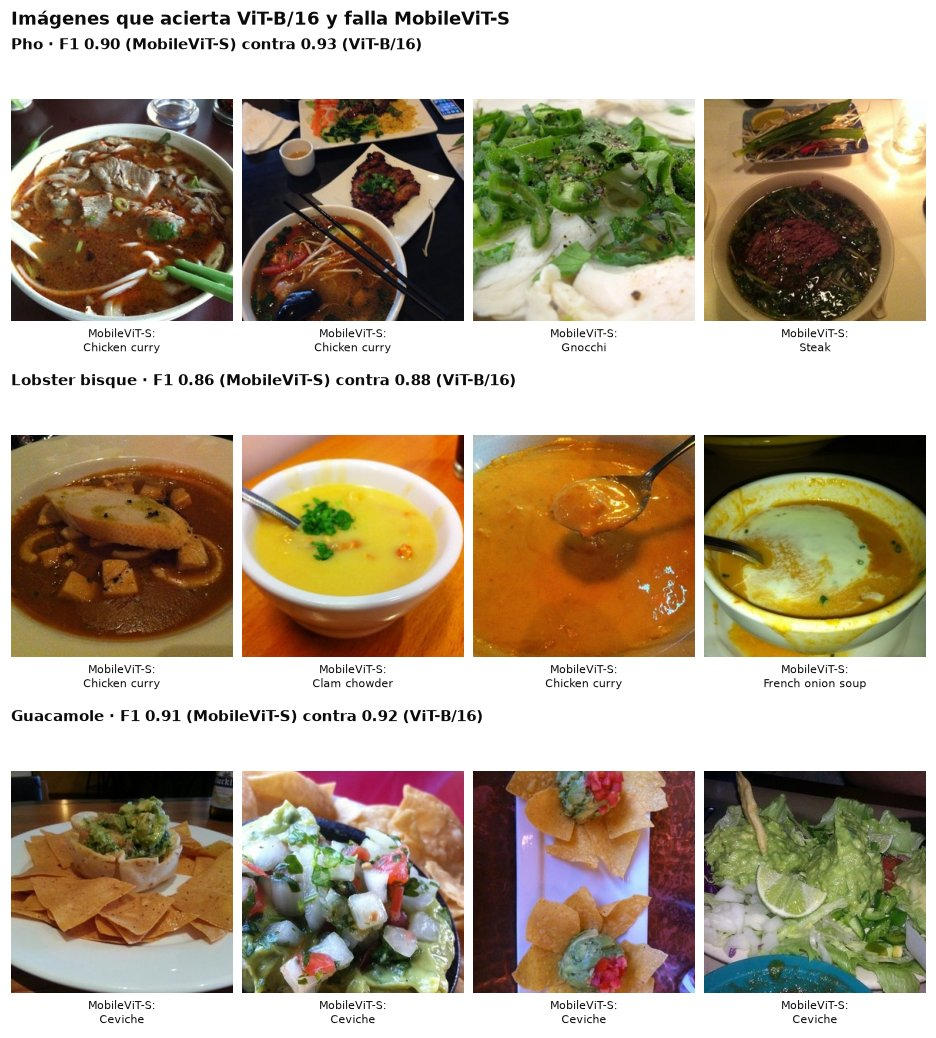

In [23]:
if hay_imagenes:
    filas = ej.rows_by_class(
        pierde,
        caption=lambda r: f"MobileViT-S:\n{etiqueta[r.pred_mobilevit]}",
        row_title=lambda c: (
            f"{etiqueta[c]} · F1 {por_clase.loc[c, 'f1_mobilevit']:.2f} (MobileViT-S) "
            f"contra {por_clase.loc[c, 'f1_' + REF]:.2f} ({NOMBRE(REF)})"
        ),
    )
    fig = ej.plot_rows(filas, rutas, f"Imágenes que acierta {NOMBRE(REF)} y falla MobileViT-S")
    mostrar_grilla(fig, "ejemplos-vit-supera-mobilevit")

Los errores de MobileViT-S en estas clases son entre preparaciones de color y consistencia parecidos: pho y lobster bisque (sopas en bowl) terminan como chicken curry, clam chowder o french onion soup, y el guacamole servido con tortillas y tomate picado, como ceviche. A diferencia de la sección anterior, acá la textura no alcanza para separar las clases y la pista está en ingredientes chicos o en el contexto de la foto. La desventaja de MobileViT-S en estas clases es chica: menos de 3 puntos de F1.

### 7.4 Errores que comparten los cuatro modelos

Imágenes que los cuatro modelos fallan **y** asignan a la misma clase equivocada. Cuando cuatro arquitecturas distintas coinciden en el error, la causa más probable está en la imagen: un plato que visualmente pertenece a otra clase, una foto donde el plato principal no es el protagonista o una etiqueta discutible.

figura: reports/figures/comparativa-ejemplos-errores-compartidos.jpg


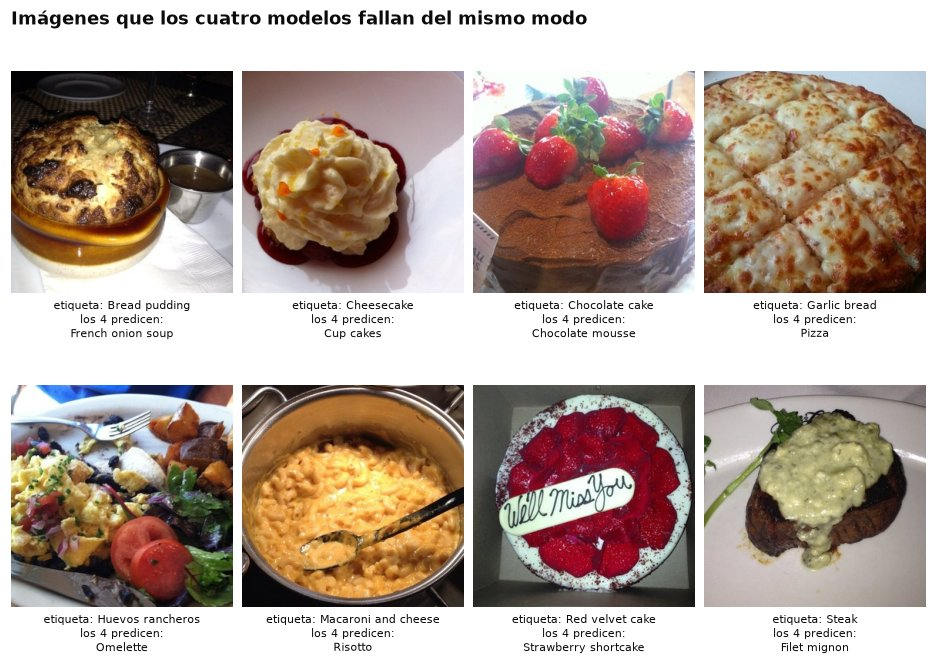

In [24]:
if hay_imagenes:
    imagenes = [
        (r.rel, f"etiqueta: {etiqueta[r.class_dir]}\nlos 4 predicen:\n{etiqueta[r.pred_mobilevit]}")
        for r in comunes.itertuples()
    ]
    filas = [("", imagenes[i : i + 4]) for i in range(0, len(imagenes), 4)]
    fig = ej.plot_rows(filas, rutas, "Imágenes que los cuatro modelos fallan del mismo modo")
    mostrar_grilla(fig, "ejemplos-errores-compartidos")

En varios de estos casos la predicción común es defendible: un garlic bread gratinado con queso es visualmente una pizza, una red velvet cubierta de frutillas se parece más a una strawberry shortcake que a su propia clase, y un bread pudding servido en cazuela de barro tiene la presentación típica de la french onion soup. Estos errores marcan un piso que no depende de la arquitectura: ninguno de los cuatro modelos los resuelve y, en varios, una persona tampoco podría decidir la clase con seguridad a partir de la foto. Es un límite a tener en cuenta al interpretar la accuracy de cualquier modelo sobre Food-101.

## 8. Convergencia y alcance de los resultados

Todo lo anterior compara **los resultados de una receta**, no el techo de cada arquitectura. Antes de sacar conclusiones hay que ver si cada corrida había terminado de aprender.

`Mejora en las últimas 3 épocas` es cuánto subió el F1 de validación al final del entrenamiento: si sigue siendo positiva al llegar al tope de 20 épocas, el modelo no convergió y su resultado es una cota inferior.

figura: reports/figures/comparativa-convergencia.png


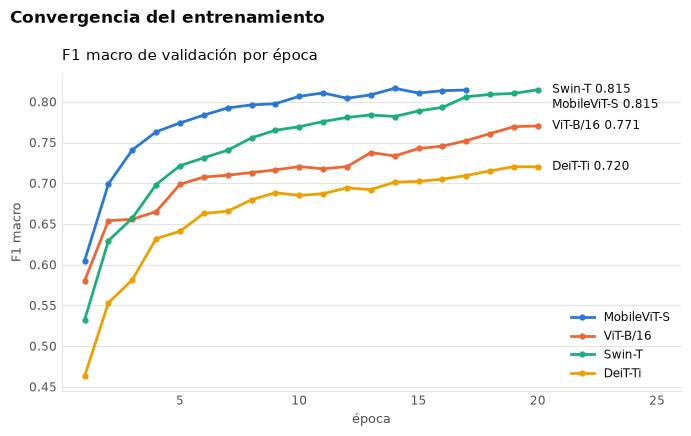

,Épocas,Mejor F1 de validación,Época del mejor F1,F1 de validación final,Mejora en las últimas 3 épocas,Pérdida de validación mínima,Época de la pérdida mínima,Pérdida de validación final
MobileViT-S,17.0,0.8167,14.0,0.8145,-0.0021,0.8264,8.0,1.0342
ViT-B/16,20.0,0.7705,20.0,0.7705,0.0181,1.1645,5.0,1.3885
Swin-T,20.0,0.8149,20.0,0.8149,0.0086,0.9200,9.0,1.2150
DeiT-Ti,20.0,0.7204,19.0,0.7203,0.0107,1.2635,8.0,1.5688


In [25]:
historiales = cmp.load_histories(MODELOS)
convergencia = cmp.convergence(historiales)
convergencia.to_csv(OUT_DIR / "convergencia.csv")

fig = cmp.plot_validation_curves(historiales)
guardar(fig, "convergencia")
plt.show()

hallazgos["modelos_sin_converger"] = [m for m in MODELOS if (convergencia.loc[m, "mejora_ultimas"] or 0) > 0]
cmp.present(convergencia)

In [26]:
val_vs_test = pd.DataFrame(
    {
        "Mejor F1 de validación": {m: metrics[m]["best_val_f1_macro"] for m in MODELOS},
        "F1 de test": {m: metrics[m]["test"]["f1_macro"] for m in MODELOS},
    }
)
val_vs_test["Test − validación"] = val_vs_test["F1 de test"] - val_vs_test["Mejor F1 de validación"]
val_vs_test.rename(index=NOMBRE)

,Mejor F1 de validación,F1 de test,Test − validación
MobileViT-S,0.8167,0.8609,0.0442
ViT-B/16,0.7705,0.8233,0.0528
Swin-T,0.8149,0.8547,0.0397
DeiT-Ti,0.7204,0.7765,0.0561


**Lectura.** Tres aspectos acotan el alcance de los resultados:

- **Convergencia.** Solo MobileViT-S dejó de mejorar antes del tope (su mejor F1 de validación fue en la época 14 y el early stopping cortó en la 17). ViT-B/16, Swin-T y DeiT-Ti seguían mejorando en la época 20: su resultado es una cota inferior de lo que pueden dar. El caso más marcado es el de la referencia, que ganó casi 2 puntos de F1 en las últimas 3 épocas. Al mismo tiempo, en los cuatro modelos la pérdida de validación toca su mínimo a mitad del entrenamiento y después sube: los modelos se vuelven más confiados en sus errores aunque la cantidad de aciertos siga creciendo.
- **Receta única.** Todos usan `learning rate = 5e-4`. Es un valor razonable para modelos chicos, pero alto para ajustar ViT-B/16 desde el checkpoint `in21k`, que suele ajustarse con valores de entre 1e-5 y 1e-4. ViT-B/16 es además el que antes alcanza su pérdida de validación mínima (época 5) y tiene una meseta de F1 entre las épocas 6 y 12, coherente con un learning rate alto. La receta única es la decisión correcta para aislar el efecto de la arquitectura, pero deja a la referencia en desventaja.
- **Validación frente a test.** El F1 de validación queda unos 4 puntos por debajo del de test en los cuatro modelos. No es una fuga: la validación sale de `train`, que tiene ruido de etiquetas a propósito, y `test` fue curado a mano. Afecta a todos por igual, así que no cambia el ranking.

A eso se suma que cada modelo se entrenó **una sola vez** (semilla 42): los intervalos de las secciones 3 y 5 cubren la variación por muestra de imágenes, no la variación entre corridas de entrenamiento.

## 9. Síntesis para el informe

Los números clave, calculados en las secciones anteriores, se exportan a `hallazgos.json` para que el informe los cite sin copiarlos a mano. Si se reentrena algún modelo, alcanza con volver a correr este notebook.

In [27]:
(OUT_DIR / "hallazgos.json").write_text(
    json.dumps(hallazgos, indent=2, ensure_ascii=False), encoding="utf-8"
)
print("guardado:", (OUT_DIR / "hallazgos.json").relative_to(REPORTS_DIR.parent))
pd.Series(hallazgos, name="valor").to_frame()

guardado: reports/results/comparativa/hallazgos.json


,valor
mobilevit_accuracy,0.8605
mobilevit_f1_macro,0.8609
vit_accuracy,0.8239
vit_f1_macro,0.8233
swin_accuracy,0.8548
swin_f1_macro,0.8547
deit_accuracy,0.7768
deit_f1_macro,0.7765
mobilevit_vs_vit_diff,0.0366
mobilevit_vs_vit_ic_bajo,0.0319


### Hallazgos principales

1. **El modelo liviano no pierde desempeño frente a la referencia.** Con la misma receta, MobileViT-S (5,0 M de parámetros) obtiene el mejor F1 macro del benchmark (0,861) y supera a ViT-B/16 (85,9 M) por unos 3,7 puntos de accuracy, con 17 veces menos parámetros, 9 veces menos GFLOPs y algo más de un tercio de su latencia en CPU int8.
2. **Swin-T iguala a MobileViT-S en desempeño, a un costo mucho mayor.** La diferencia entre ambos es de poco más de medio punto, pero Swin-T tiene 5,5 veces más parámetros y es más lento en CPU.
3. **El tamaño no alcanza: la arquitectura importa.** DeiT-Ti, con casi los mismos parámetros que MobileViT-S, queda unos 8 puntos por debajo. Es, en cambio, el más rápido en CPU (unos 19 ms contra 75 ms), así que es la alternativa si la latencia es la restricción dominante.
4. **Las diferencias se concentran en las clases difíciles.** La ventaja de MobileViT-S sobre la referencia pasa de unos 1,7 puntos en el tercil fácil a unos 5,1 en el difícil, y su correlación con el margen de dificultad del EDA es negativa (ρ ≈ −0,33). MobileViT-S le gana a la referencia en 94 de 101 clases.
5. **Hay un núcleo de errores que no depende del modelo.** Las confusiones dominantes (steak ↔ filet mignon, chocolate cake ↔ chocolate mousse, los dos tartares) son las mismas en las cuatro arquitecturas; el 5,7 % del test lo fallan todas, y en 331 imágenes coinciden en la misma clase equivocada.

### Limitaciones

- Una sola receta y una sola semilla por modelo.
- La referencia no convergió y el learning rate compartido es alto para ViT-B/16: su 82 % es una cota inferior. Lo que el benchmark sostiene con firmeza es que **MobileViT-S no pierde frente a la referencia en condiciones idénticas**; afirmar que la supera en general requiere reentrenar ViT-B/16 con un learning rate más bajo.
- Las latencias se midieron en la CPU de una notebook (un hilo), no en un dispositivo móvil real. Sirven para comparar modelos entre sí, no para predecir la latencia absoluta en un teléfono.

## 10. Artefactos generados

In [28]:
for p in sorted(OUT_DIR.iterdir()):
    print(" -", p.relative_to(REPORTS_DIR.parent))
for p in sorted(FIGURES_DIR.glob("comparativa-*")):
    print(" -", p.relative_to(REPORTS_DIR.parent))

 - reports/results/comparativa/accuracy_por_tercil_subset.csv
 - reports/results/comparativa/brecha_por_clase.csv
 - reports/results/comparativa/brecha_por_tercil_subset.csv
 - reports/results/comparativa/brecha_por_tercil_test.csv
 - reports/results/comparativa/brecha_vs_dificultad.csv
 - reports/results/comparativa/confusiones_compartidas.csv
 - reports/results/comparativa/convergencia.csv
 - reports/results/comparativa/diferencias_entre_candidatos.csv
 - reports/results/comparativa/diferencias_vs_referencia.csv
 - reports/results/comparativa/frente_de_pareto.csv
 - reports/results/comparativa/hallazgos.json
 - reports/results/comparativa/tabla_comparativa.csv
 - reports/figures/comparativa-brecha-por-clase-mobilevit.png
 - reports/figures/comparativa-brecha-por-clase-swin.png
 - reports/figures/comparativa-brecha-por-tercil.png
 - reports/figures/comparativa-convergencia.png
 - reports/figures/comparativa-ejemplos-errores-compartidos.jpg
 - reports/figures/comparativa-ejemplos-mobil